*Credit Card Fraud Detection***

**Dataset:** credtcard.csv

Highly Imbalanced Dataset

1.Setup

In [6]:
#install the required libraries
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics  import(
    accuracy_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
)

In [10]:
#configuration
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x: f"{x:3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE=42

2.Load Dataset

In [11]:
df= pd.read_csv("creditcard.csv")

3.Exploration Data Analysis(EDA)

In [12]:
df.shape

(284807, 31)

In [13]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000,0
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0
2,1.000000,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000,0
3,1.000000,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0
4,2.000000,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000,0


class: 
0 --> Non Fraud,
1 --> Fraud

In [14]:
#basic overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [15]:
#Missing values
df.isna().sum().sort_values(ascending=False)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [16]:
#quick checks for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))


Time
163152.000000    36
64947.000000     26
68780.000000     25
3767.000000      21
3770.000000      20
3750.000000      19
19912.000000     19
128860.000000    19
140347.000000    19
143083.000000    18
Name: count, dtype: int64
V1
1.245674    77
2.055797    77
2.053311    62
1.302378    60
2.040211    53
2.085175    48
1.332849    45
1.018412    40
1.335053    39
1.315404    36
Name: count, dtype: int64
V2
0.166975     77
-0.326668    77
0.089735     62
-0.606529    60
-0.146975    53
0.393051     48
0.389198     45
1.036663     40
0.331464     39
-0.033577    36
Name: count, dtype: int64
V3
0.488306     77
-2.752041    77
-1.681836    62
-0.681986    60
-2.955934    53
-4.508201    48
-2.165597    45
-1.689814    40
-2.057763    39
-1.089984    36
Name: count, dtype: int64
V4
0.635322     77
-0.842316    77
0.454212     62
-1.904603    60
-0.578356    53
-0.311771    48
-0.306873    45
1.315476     40
-0.346175    39
-0.557087    36
Name: count, dtype: int64
V5
-0.562777    77
2.46

In [17]:
#duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of Duplicate rows:", num_duplicates)


Number of Duplicate rows: 1081


In [18]:
#target distribution
print(df["Class"].value_counts())
print("-"*50)
print(df["Class"].value_counts(normalize=True)*100)

Class
0    284315
1       492
Name: count, dtype: int64
--------------------------------------------------
Class
0   99.827251
1    0.172749
Name: proportion, dtype: float64


Note: Data is Highly Imbalanced

In [19]:
#imbalance ratio
n_fraud = (df["Class"] ==1).sum()
n_nonfraud = (df["Class"] == 0).sum()
print("\n Imbalance ration(non-fraud:fraud)=",round(n_nonfraud / max(n_fraud,1),2))



 Imbalance ration(non-fraud:fraud)= 577.88


Inference: 1 fraud transaction for 577 non-fraud transaction

In [20]:
#descriptive stats for key columns
df[["Time","Amount"]].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


Data Visualization

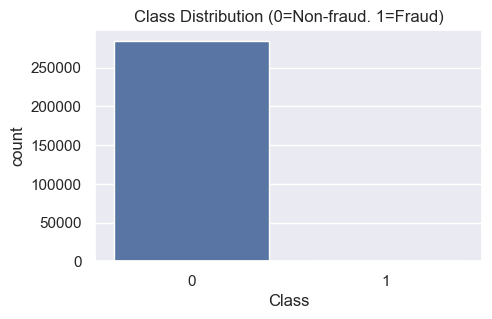

In [21]:
#visualize class imbalance
plt.figure(figsize=(5,3))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0=Non-fraud. 1=Fraud)")
plt.show()


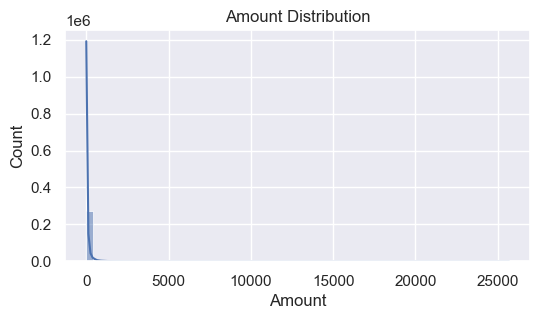

In [22]:
#Amount Distribution (raw)
plt.figure(figsize=(6,3))
sns.histplot(df["Amount"],bins=60, kde=True)
plt.title("Amount Distribution")
plt.show()

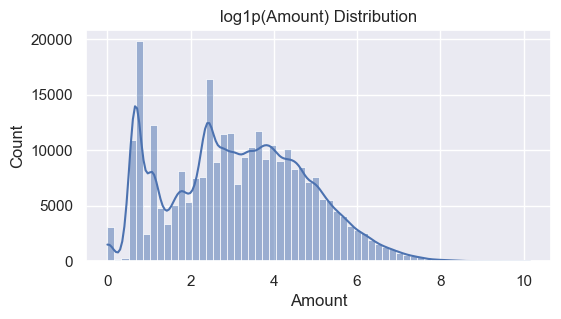

In [23]:
#Amount distribution (raw + log1p)
plt.figure(figsize=(6,3))
sns.histplot(np.log1p(df["Amount"]), bins=60, kde=True)
plt.title("log1p(Amount) Distribution")
plt.show()

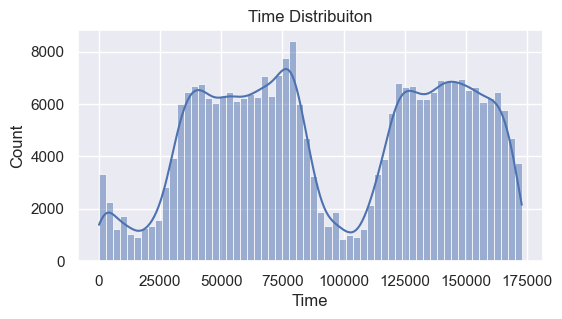

In [24]:
#Time Distribution
plt.figure(figsize=(6,3))
sns.histplot(df["Time"], bins=60, kde=True)
plt.title("Time Distribuiton")
plt.show()

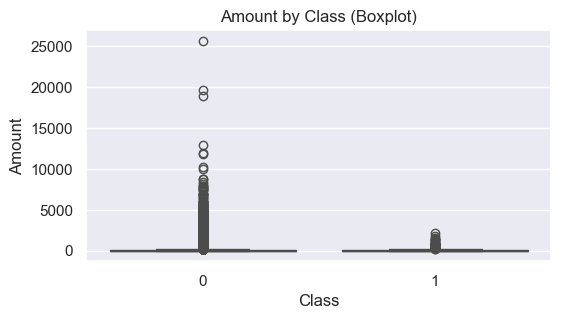

In [25]:
#Amount by class (help intuition)
plt.figure(figsize=(6,3))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount by Class (Boxplot)")
plt.show()

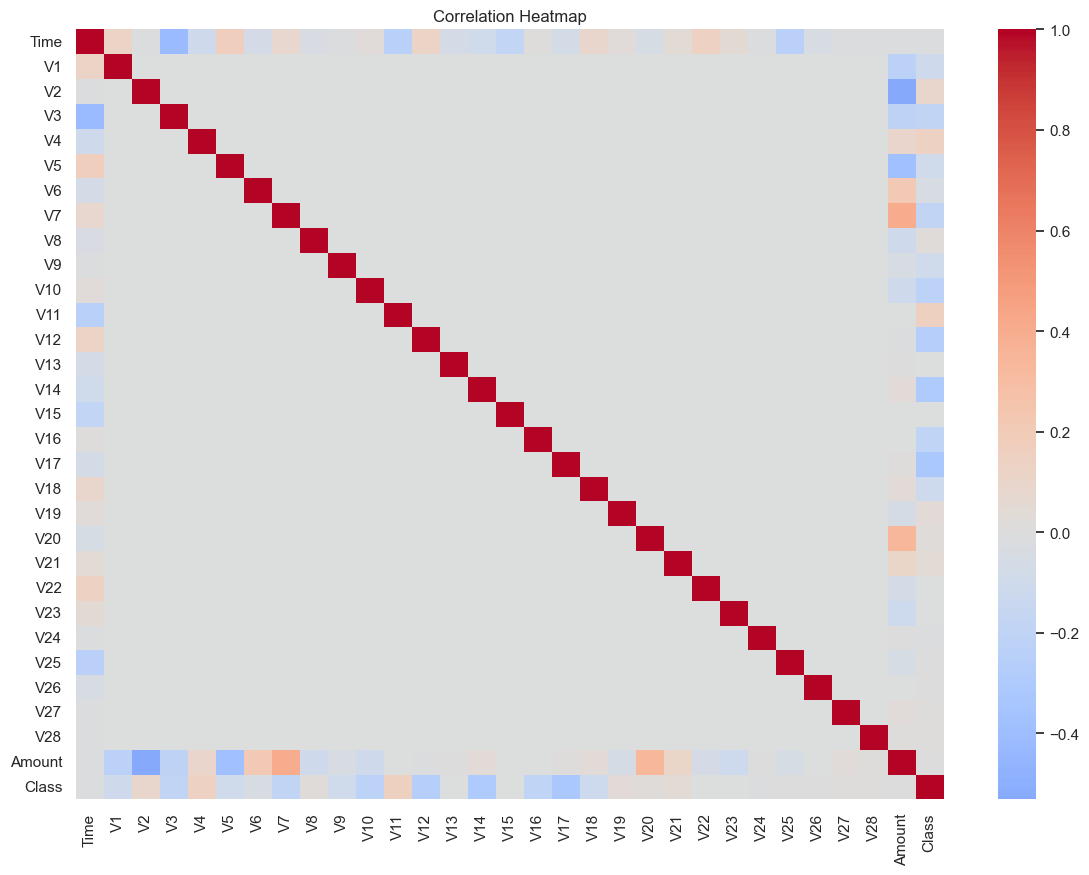

In [26]:
#correlation heatmap (can be heavy but useful)
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

There are no highly correlated columns(probably because of PCA applied Columns)

In [27]:
#correlation with target (top signals)
corr_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
corr_target.head(5),corr_target.tail(5)

(Class   1.000000
 V11     0.154876
 V4      0.133447
 V2      0.091289
 V21     0.040413
 Name: Class, dtype: float64,
 V16   -0.196539
 V10   -0.216883
 V12   -0.260593
 V14   -0.302544
 V17   -0.326481
 Name: Class, dtype: float64)

4.Data preprocessing

In [28]:
#Add log1p(Amount) for stability
df["Amount_log1p"] = np.log1p(df["Amount"])

In [29]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Amount_log1p'],
      dtype='str')

In [30]:
#Seperate features and target
X = df.drop(columns=["Class","Amount"]) #removing amount as we have amount_log1p
y = df["Class"]

In [31]:
#Train test split
X_train, X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [32]:
print("Dataset Shape:", X.shape)
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

Dataset Shape: (284807, 30)
Training Data Shape: (227845, 30)
Test Data Shape: (56962, 30)


5.BaseLine model

In [34]:
base_pipeline = Pipeline(
    [
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [35]:
#train the model
base_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If f

In [36]:
y_base_train_pred = base_pipeline.predict(X_train)
y_base_test_pred = base_pipeline.predict(X_test)

In [37]:
base_train_acc = round(accuracy_score(y_train, y_base_train_pred)*100,3)
base_test_acc = round(accuracy_score(y_test,y_base_test_pred)*100 ,3)
print("Baseline Train Accuracy:", base_train_acc)
print("Baseline Test Accuracy:", base_test_acc)

Baseline Train Accuracy: 100.0
Baseline Test Accuracy: 99.914


In [38]:
print("Train- Classification Report")
print(classification_report(y_train, y_base_train_pred))

Train- Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



Note: Accuracy score is not reliable because of class imbalance 

In [39]:
#Average precision score or pr-auc
y_train_prob = base_pipeline.predict_proba(X_train)[:,1]
print("Training Average Precision Score:",average_precision_score(y_train, y_train_prob))

Training Average Precision Score: 1.0


In [40]:
#Average precision score or pr-auc
y_test_prob = base_pipeline.predict_proba(X_test)[:,1]

print(
    "Test Average Precision Score:",
    average_precision_score(y_test, y_test_prob)
)

Test Average Precision Score: 0.5610321985726947


6.Model & Optimiztion

In [41]:
k=5
cv=StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)


In [42]:
models = {

    "dt_balanced": Pipeline(
        [
            ("model", DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
                ))
        ]
    ),

    "hgb_balanced": Pipeline(
        [
            ("model", HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
                ))
        ]
    ),

    "rf_balanced": Pipeline(
        [
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"))
        ]
    ),

    
}

In [43]:
for name, m in models.items():
    print(name,m)

dt_balanced Pipeline(steps=[('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])
hgb_balanced Pipeline(steps=[('model',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                random_state=42))])
rf_balanced Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])


In [44]:
# Cross Validation Model Evaluation

for name, m in models.items():

    pr_auc_scores = []

    # Stratified Cross Validation
    for tr_idx, te_idx in cv.split(X_train, y_train):

        # Split fold data
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]

        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        # Train model
        m.fit(X_tr, y_tr)

        # Predict probabilities
        y_prob = m.predict_proba(X_te)[:, 1]

        # Calculate PR-AUC
        pr_auc = average_precision_score(y_te, y_prob)

        # Store score
        pr_auc_scores.append(pr_auc)

    # Print Average Score
    print(f"{name} Mean PR-AUC: {np.mean(pr_auc_scores):.4f}")

dt_balanced Mean PR-AUC: 0.5366
hgb_balanced Mean PR-AUC: 0.7462
rf_balanced Mean PR-AUC: 0.8394


**Best Model as per model selection process:Random Forest Classifier**

Hyper Parameter tuning for random forest classifier

In [45]:
rfc_pipeline =Pipeline([
    ("model",RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

In [47]:
#hyperparameter tuining - Random Forest Classifier
param_dist = {
    "model__n_estimators": [200,300,500],
    "model__max_depth": [None,10,20,30],
    "model__min_samples_leaf":[1,5,10,20],
    "model__max_features":["sqrt","log2",0.5]
}

In [50]:
#random search 
random_search =RandomizedSearchCV(
    estimator=rfc_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision", #PR-AUC
    cv=cv,
    verbose=True
)

In [54]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [200, 300, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-

In [57]:
print("Best CV PR-AUC:",round(random_search.best_score_,4))
print("Best params:", random_search.best_params_)

Best CV PR-AUC: 0.8374
Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': None}


7.Re-train with best parameters

In [59]:
best_rfc = Pipeline(
    [
        ("model",RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            max_features="log2",
            max_depth=30,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]
)

In [60]:
#train best rfc
best_rfc.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If fl

Model Ealuation

In [62]:
#training data prediction
y_train_pred = best_rfc.predict(X_train)


In [63]:
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy:{round(train_acc*100,2)}%")

Training Accuracy:100.0%


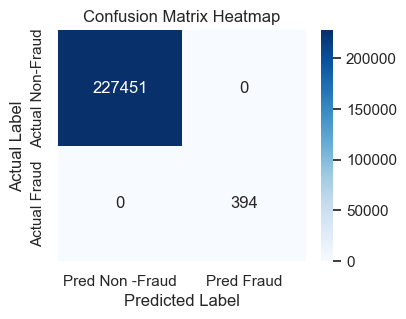

In [66]:
#confusion matrix 
cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(4,3))
#heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Non -Fraud", "Pred Fraud"],
    yticklabels=["Actual Non-Fraud", "Actual Fraud"]
    
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [67]:
print("Training Classification report")
print(classification_report(y_train,y_train_pred))

Training Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



In [69]:
train_prob = best_rfc.predict_proba(X_train)[:,1]
print("Train PR-AUC:",round(average_precision_score(y_train, train_prob),4))

Train PR-AUC: 1.0


In [70]:
#test data prediction
y_test_pred = best_rfc.predict(X_test)

In [73]:
test_acc = accuracy_score(y_test,y_test_pred)
print(f"Test Accuracy:{round(test_acc*100,2)}%")

Test Accuracy:99.95%


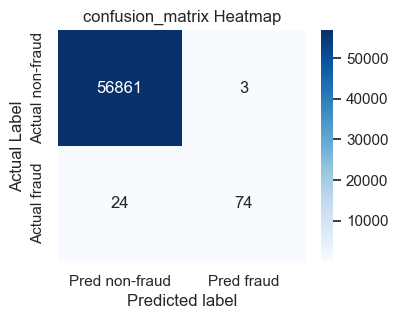

In [77]:
#confusion Matrix 
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(4,3))
#heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred non-fraud", "Pred fraud"],
    yticklabels=["Actual non-fraud","Actual fraud"]
)
plt.xlabel("Predicted label")
plt.ylabel("Actual Label")
plt.title("confusion_matrix Heatmap")
plt.show()

In [78]:
print("Test Classification report")
print(classification_report(y_test, y_test_pred))

Test Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [79]:
test_proba= best_rfc.predict_proba(X_test)[:,1]
print("Test PR-AUC:",round(average_precision_score(y_test, test_proba),4))

Test PR-AUC: 0.8679


8.Build a predictive system

In [80]:
def predict_class(input_features):

    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )

    # get prediction from trained model
    prediction = best_rfc.predict(input_df)

    print("Model prediction:", prediction)

    if prediction[0] == 1:
        print("Fraud Transaction Detected ❌💳")

    else:
        print("Non-Fraud Transaction ✅💳")

In [81]:
X_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log1p
263020,160760.000000,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,0.650757,-0.857785,-0.229961,-0.199817,0.266371,-0.046544,-0.741398,-0.605617,-0.392568,-0.162648,0.394322,0.080084,0.810034,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,3.178054
11378,19847.000000,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,-1.000418,1.850842,-1.549779,1.252337,0.963974,-0.481027,-0.147319,-0.209328,1.058898,0.397057,-0.515765,-0.295555,0.109305,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,2.553344
147283,88326.000000,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,7.398491,2.081146,-0.064145,0.577556,-2.430201,1.505993,-1.237941,-0.390405,-1.231804,0.098738,2.034786,-1.060151,0.016867,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,4.344714
219439,141734.000000,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,0.047859,-0.652497,0.750829,0.665603,0.158608,0.027348,-0.171173,-0.291228,-1.008531,0.097040,-0.192024,-0.281684,-0.639426,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,0.688135
36939,38741.000000,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,-1.579654,1.462573,0.208823,0.734537,-3.538625,0.926076,0.835029,2.845937,1.040947,-1.045263,0.009083,-0.164015,-0.328294,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,0.916291


In [82]:
y_test.head()

263020    0
11378     0
147283    0
219439    0
36939     0
Name: Class, dtype: int64

In [84]:
y_test[y_test ==0 ].head()

263020    0
11378     0
147283    0
219439    0
36939     0
Name: Class, dtype: int64

In [85]:
y_test[y_test ==1].head()

77348     1
102442    1
119781    1
48094     1
42958     1
Name: Class, dtype: int64

In [87]:
test_1=X_test.loc[263020].tolist()
print(test_1)

[160760.0, -0.674466064578314, 1.40810501967799, -1.11062205357093, -1.32836577843066, 1.38899603254837, -1.30843906707795, 1.88587890268717, -0.614232966299775, 0.311652212453101, 0.65075700363522, -0.857784661547805, -0.229961445775592, -0.19981700479103, 0.266371326329879, -0.0465441684754424, -0.741398089749789, -0.605616644106022, -0.39256818789208, -0.162648311024695, 0.394321820843914, 0.0800842396026648, 0.810033595602455, -0.224327230436412, 0.707899237446867, -0.13583702273753, 0.0451021964988772, 0.533837219064273, 0.291319252625364, 3.1780538303479458]


In [88]:
predict_class(test_1)

Model prediction: [0]
Non-Fraud Transaction ✅💳


In [89]:
test_2=X_test.loc[77348].tolist()
print(test_2)

[57007.0, -1.27124419171437, 2.46267526851135, -2.85139500331783, 2.3244800653478, -1.37224488981369, -0.948195686538643, -3.06523436172054, 1.16692694787211, -2.26877058844813, -4.88114292689057, 2.25514748870463, -4.68638689759229, 0.652374668512965, -6.17428834800643, 0.594379608016446, -4.84969238709652, -6.53652073527011, -3.11909388163881, 1.71549441975915, 0.560478075726644, 0.652941051330455, 0.0819309763507574, -0.221347831198339, -0.523582159233306, 0.224228161862968, 0.756334522703558, 0.632800477330469, 0.250187092757197, 0.009950330853168083]


In [90]:
predict_class(test_2)

Model prediction: [1]
Fraud Transaction Detected ❌💳
